# 멋진 GPT 만들기
참고 논문 : [GPT](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)
- 논문에서 pre-train 까지만 구현 : 디코드만 활용해서 말뭉치 입력 -> 예상되는 대답 출력
- fine tunning 제외

### Quest 문제 1. Transformer와 비교해 변경이 필요한 부분을 서술하였다
변경이 필요한 부분
- 인코더가 없다
- Masked Multi Self Attention 만 있다 (인코드 연결 받고, 크로스 어텐션 없음)
- 포지셔닝 인코딩이 없고 임베딩으로 바꼈다

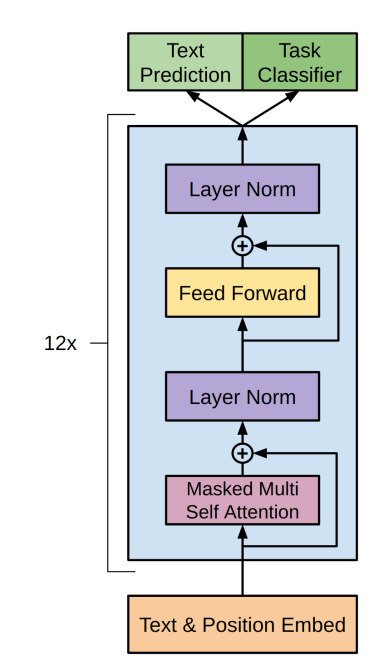

## 전체 프로세스 흐름

<details>
<summary>데이터 수집 → 전처리 → 토크나이저 학습 → 모델 학습 → 생성/평가</summary>

1. 환경 설정
   KoNLPy + NLP 라이브러리 설치
2. 데이터 준비 (ChatbotData.csv)
    - 11823개 Q&A 쌍 → Train(9458) / Val(1655) / Test(710)
        - 질문/답변 전처리 (소문자, 특수문자 제거)
        - KoNLPy(Okt/Mecab) 형태소 분석 → 6688개 corpus
3. 데이터 증강 (Lexical Substitution)
    - ko.kv (Word2Vec 한국어 임베딩) 사용
        - 원본: 6688개
        - 증강 후: 20064개 (3배: Q↔A 교차, 원본)
    - most similar 단어 치환으로 다양성↑
4. 토크나이저 학습 (SentencePiece)
5. 데이터셋 구성
    - QADataset + DataLoader (batch=64)
        - pad_sequence (PAD=0, maxlen=50)
        - BOS Q SEP A EOS 시퀀스 생성
    - torch.Size([20064, 50]) 형태
6. Transformer 모델
    - Encoder-Decoder 구조 (nlayers=2, dmodel=512, nheads=8, dff=2048) -> Decoder 로 변경
        - MultiHeadAttention (Scaled Dot-Product)
        - Positional Encoding (sin/cos)
        - Noam Learning Rate (warmup=4000)
        - AdamW optimizer
7. 학습 루프 (20 epochs)
```
    for epoch in EPOCHS:
        train_step() → val_step() → EarlyStopping(patience=3)
```
9. 생성(Inference)
    - generate_answer_from_question()
        - prompt: BOS Q SEP
        - autoregressive decoding (top-k=20, temp=0.8)
        - EOS(2)까지 생성

- 결과 요약

<div style="display: table; margin-left: 0;">
    
| 단계    | 주요 작업          | 출력 크기          |
| :----- | :------------- | :------------- |
| 증강    | Lexical Sub    | 6688 → 20064   |
| 토크나이저 | SentencePiece  | vocab=3063     |
| 데이터셋  | Train/Val/Test | 20064/1542/673 |
| 학습    | Transformer    | Loss↓ Acc↑ 71% |

</div>

***전체: CSV → 전처리 → 증강 → SP 토큰화 → Transformer 학습 → 챗봇 생성 완성!***
</details>

### 사전 환경 설치

<details>
<summary>Mecab + NLTK + gensim + SentencePiece + rouge-score 설치</summary>
    
#### Ubuntu KoNLPy 설치
```
$ sudo apt-get install g++ openjdk-8-jdk
$ sudo apt-get install curl

# Mecab 설치 에러: $ bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

# 위 실행후 에러 발생한다음 아래로 설치해서 성공
$ sudo apt-get install -y libmecab-dev python3-dev build-essential

$ pip install mecab-python3

# Mecab 설치 확인
$ mecab -v

$ pip install konlpy
```
#### 추가 설치
```
$ pip install gensim   # 토픽 모델링(LDA 등), 문서/단어 임베딩(Word2Vec, Doc2Vec), 문서 유사도 계산 등을
                       #    지원하는 NLP용 라이브러리(Natural Language Processing, 자연어 처리)
$ pip install nltk     # 자연어 처리 라이브러리
$ pip install sentencepiece  # Google에서 개발한 언어 독립적 서브워드 토크나이저로,
                             #   BPE나 unigram 알고리즘을 사용해 raw 텍스트에서 직접 토큰을 학습·생성
                             # 사전 토큰화(pre-tokenization) 없이 띄어쓰기나 언어 규칙에 구애받지 않고
                             # 모든 언어(한국어·영어·중국어 등)에 적용 가능
                             # 여기서는 pre-tokenization: Mecab or Okt  -> sentencepiece
$ pip install rouge-score    # LLM 요약, 기계번역, 텍스트 생성 모델의 성능을 객관적으로 평가할 때 표준으로 사용
```
</details>

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from konlpy.tag import Mecab
from gensim.models import KeyedVectors
from tqdm import tqdm
import os
import math
import nltk
import gensim
import re

print(np.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.2.6
2.3.0
2.7.1+cu118
3.9.3
4.4.0


In [86]:
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),
    "AUG_DATA": "data/ko.kv",   # "data/ko.kv"
    "BATCH_SIZE": 64,
}

device = CFG["DEVICE"]

# Data 준비

## Step 1. 데이터 다운로드

### Data 다운로드

In [19]:
url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(url)
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### questions, answers 변수에 나눠서 저장

In [20]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


## Step 2. 데이터 정제
### preprocess_sentence() 함수를 구현하세요.
- 영문자의 경우, 모두 소문자로 변환합니다.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

In [21]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [22]:
after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


## Step 3. Data 분리

In [23]:
from sklearn.model_selection import train_test_split

# que_corpus, ans_corpus: 같은 길이의 리스트 (문장 문자열이든 토큰 리스트든 상관 없음)

# 1) 먼저 train(80%) / test(20%) 분리
que_train, que_vt, ans_train, ans_vt = train_test_split(
    questions,
    answers,
    test_size=0.2,
    shuffle=True,
    random_state=42,
)

# val(70%) / test(30%) 분리
que_val, que_test, ans_val, ans_test = train_test_split(
    que_vt,
    ans_vt,
    test_size=0.3,
    shuffle=True,
    random_state=42,
)

total_que_cnt = len(que_train) + len(que_val) + len(que_test)
total_ans_cnt = len(ans_train) + len(ans_val) + len(ans_test)

In [24]:
print(f"total questions len: {total_que_cnt}, train: {len(que_train)} : {(len(que_train)/total_que_cnt)*100:.1f}%, \
      val: {len(que_val)} : {(len(que_val)/total_que_cnt)*100:.1f}%, test: {len(que_test)} {(len(que_test)/total_que_cnt)*100:.1f}%")
print(f"total answers len: {total_ans_cnt}, train: {len(ans_train)} : {(len(ans_train)/total_ans_cnt)*100:.1f}%, \
      val: {len(ans_val)} : {(len(ans_val)/total_ans_cnt)*100:.1f}%, test: {len(ans_test)} {(len(ans_test)/total_ans_cnt)*100:.1f}%") 

total questions len: 11823, train: 9458 : 80.0%,       val: 1655 : 14.0%, test: 710 6.0%
total answers len: 11823, train: 9458 : 80.0%,       val: 1655 : 14.0%, test: 710 6.0%


## Step 4. Train data 처리 : 
증강 -> pre_tokenizer -> SentencePiece 학습 (vocab 생성)

### 4-1. 데이터 증강 (Augmentation) : Train data only

주어진 약 1만 개의 데이터를 기반으로 **Lexical Substitution(어휘 치환)** 기술을 적용하여 데이터를 증강합니다. 이를 위해 한국어 사전 훈련된 Embedding 모델(`ko.bin`)을 활용하며, 전체 데이터가 원본 대비 **3배**가 되도록 구성하는 요구사항을 이행합니다.

<details>
    <summary> 요구사항 이행 내용 </summary>

#### ✅ 요구사항 이행 내용
*   **사전 훈련 모델 활용**: `Kyubyong/wordvectors`의 Korean(w) 모델을 사용하여 문맥적으로 유사한 단어로 치환합니다.
*   **3배 증강 전략 적용**:
    1. **1배수**: `Augmented Questions` + `Original Answers` (질문만 변형)
    2. **2배수**: `Original Questions` + `Augmented Answers` (답변만 변형)
    3. **3배수**: `Original Questions` + `Original Answers` (원본 유지)

---

#### 🛠️ 기술적 해결 과정: `ko.bin`에서 `ko.kv`로의 변환
다운로드한 `ko.bin` 파일이 최신 파이썬(3.12) 및 Gensim(4.4.0) 환경과 호환되지 않는 문제(AttributeError)를 다음과 같이 해결하였습니다.

1.  **문제 파악**: `ko.bin`은 구버전 파이썬의 **Pickle** 방식으로 저장되어 최신 라이브러리 구조와 충돌이 발생했습니다.
2.  **원본 데이터 활용**: 압축 파일에 함께 포함된 텍스트 형식의 **[ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)** 파일(단어와 벡터값이 명시된 원본)을 확보했습니다.
3.  **변환 로직 수행**:
    *   [ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)를 파싱하여 30,185개의 단어와 각 200차원의 숫자 벡터를 추출했습니다.
    *   현대적이고 효율적인 바이너리 저장 방식인 **KeyedVectors** 객체로 재조립했습니다.
4.  **최적화 결과 (`ko.kv`)**: 
    *   **호환성**: 현재 환경에서 직접 생성하여 오류 없이 즉시 로드됩니다.
    *   **경량화**: 불필요한 메타데이터를 제거하여 용량을 약 **25MB**로 최적화했습니다.
    *   **성능**: `load()` 속도가 0.1초 내외로 매우 빠르며 `most_similar()` 기능을 완벽히 지원합니다.

이제 이 고성능 `ko.kv` 모델을 사용하여 안정적으로 증강 작업을 진행할 수 있습니다.
</details>

In [25]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442)]


In [26]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    랜덤하게 한 단어를 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 문장에서 랜덤하게 단어 하나 선택
        _from = random.choice(toks)
        # 선택한 단어와 유사한 단어 TOP 10 중 하나 무작위 선택
        candidates = word2vec.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except:
        # 사전에 단어가 없거나 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료")

lexical_sub 함수 정의 완료


In [27]:
# 증강 데이터를 임시로 담을 리스트
added_que_corpus = []
added_ans_corpus = []

# 원본 데이터 개수 백업 (반복문에 사용)
original_len = len(que_train)

# 1단계: [Augmented Q] + [Original A] (1:1 매칭으로 1배수 추가)
print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_train[i], word2vec))
    added_ans_corpus.append(ans_train[i])

# 2단계: [Original Q] + [Augmented A] (또 다른 1:1 매칭으로 총 2배수 추가)
print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_train[i])
    added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))

# 기존 원본 코퍼스에 증강된 2배 분량의 데이터를 합치기 (최종 3배)
que_train += added_que_corpus
ans_train += added_ans_corpus

print(f"✅ 증강 완료 (최종 약 2만 개 가량 확보, 원본의 3배)!")
print(f"최종 코퍼스 크기: {len(que_train)}")


1단계 증강 중: Augmented Q + Original A...


100%|██████████| 9458/9458 [00:00<00:00, 804986.35it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 9458/9458 [00:00<00:00, 845962.66it/s]

✅ 증강 완료 (최종 약 2만 개 가량 확보, 원본의 3배)!
최종 코퍼스 크기: 28374


### 4-2. 데이터 토큰화((`build_corpus`) : train 먼저, 나중에 val, test 진행
이 섹션에서는 한국어 형태소 분석기인 **Mecab**을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축합니다.
Mecab 설치 에러시 Okt 사용
<details>
<summary>상세내용 (클릭해서 펼치기)</summary>

### 1. 토크나이저 설정 (Mecab) : 설치 에러시 -> Okt 사용
* **환경별 최적화**: Apple Silicon(MPS) 환경인 경우 사전 경로를 직접 지정하고, 그 외의 경우 기본 설정을 사용하여 `mecab` 인스턴스를 생성합니다.
### 2. 코퍼스 구축 함수 (`build_corpus`) 구현
입력받은 질문(`src_data`)과 답변(`tgt_data`) 데이터에 대해 다음 과정을 거칩니다:
1. **정제**: `preprocess_sentence`를 통해 문장을 깨끗하게 만듭니다.
2. **토큰화**: 전달받은 `tokenize_func`(Mecab)을 사용하여 형태소 분석을 수행합니다.
3. **길이 제한**: 토큰 개수가 `max_len`(50) 이하인 문장 쌍만 선택합니다.
4. **중복 제거**: 질문과 답변을 각각 독립적으로 체크하여 중복된 문장이 포함된 쌍을 제거합니다.
#### 3. 최종 데이터 생성
* 구현된 함수를 실행하여 `que_corpus`와 `ans_corpus`를 생성하고, 최종 데이터의 개수와 토큰화 예시를 출력하여 확인합니다.

### 데이터 분리 → 토큰화하기
- 토큰화를 먼저 하면, 전체 데이터를 토큰화하면서 Test 세트에만 있는 단어나 통계적 정보가 Train 세트의 단어 사전에 포함되어 버린다.
- (정석대로라면) 모델이 공부하기도 전에 시험 문제를 미리 엿보는 꼴이 되어, 실제 실력보다 점수가 높게 나오는 '가짜 성능'이 발생한다고 한다
- 모든 데이터를 한꺼번에 넣고 진행하던 것 → train set만 토큰화(단어장용), 증강 진행
- 참고 : 인코딩을 말하는 토큰화는 Train/Val/Test 모두에 해야 한다
</details>

In [28]:
def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs or Okt.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus

In [29]:
# 토크나이저 학습은 Train 데이터로만
# ❌ 전체 데이터 사용 (Data Leakage 위험)
# ✅ Train만 사용 (권장)

try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    test_sentence = mecab.morphs("안녕하세요")
    print("✅ Mecab 사용")
    pre_tokenizer = mecab.morphs
except:
    print("❌ Mecab 실패 → OKT 사용")
    from konlpy.tag import Okt
    pre_tokenizer = Okt().morphs

que_train_corpus, ans_train_corpus = build_corpus(que_train, ans_train, pre_tokenizer, max_len=CFG["PRE_MAX_LEN"])

    
# 결과 확인
print(f"최초 질문 코퍼스 크기: {len(que_train)}")
print(f"최종 질문 코퍼스 크기: {len(que_train_corpus)}")
print(f"최종 답변 코퍼스 크기: {len(ans_train_corpus)}")

if len(que_train_corpus) > 0:
    print(f"질문 예시: {que_train_corpus[:5]}")
    print(f"답변 예시: {ans_train_corpus[:5]}")

✅ Mecab 사용
최초 질문 코퍼스 크기: 28374
최종 질문 코퍼스 크기: 6688
최종 답변 코퍼스 크기: 6688
질문 예시: [['엄청', '로맨틱', '해'], ['대리', '님', '이', '너무', '갈궈'], ['사내', '커플', '인데', '비밀', '연애', '임', '.', '답답', '해', '.'], ['그', '사람', '이', '참', '그리워'], ['왜']]
답변 예시: [['생각', '만', '해도', '달콤', '하', '네요', '.'], ['더', '웃', '으면서', '대해', '보', '세요', '.'], ['비밀', '연애', '가', '말', '도', '못하', '고', '힘들', '죠', '.'], ['사랑', '했', '나', '봐요', '.'], ['궁금', '하', '네요', '.']]


### 4-3. 데이터 벡터화 (tokenizer 모델 및 객체 생성 + vacab 생성)

In [30]:
def generate_tokenizer(corpus,
                       vocab_size,
                       lang="kor",
                       pad_id=0,   # pad token의 일련번호
                       bos_id=1,  # 문장의 시작을 의미하는 bos token(<s>)의 일련번호
                       eos_id=2,  # 문장의 끝을 의미하는 eos token(</s>)의 일련번호
                       unk_id=3):   # unk token의 일련번호
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
        for row in corpus: f.write(" ".join(row) + '\n')

    import sentencepiece as spm
    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    spm.SentencePieceTrainer.Train(
        f'--input={file} '
        f'--model_prefix={model} '
        f'--vocab_size={vocab_size} '
        f'--pad_id={pad_id} '
        f'--bos_id={bos_id} '
        f'--eos_id={eos_id} '
        f'--unk_id={unk_id} '
        f'--user_defined_symbols=<sep>'  # delim 용으로 추가
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')

    return tokenizer

print("슝=3")

슝=3


In [33]:
vocab_size = 2881  # 20000 후 에러 로그보고 최대치로 셋팅

tokenizer = generate_tokenizer(que_train_corpus + ans_train_corpus, vocab_size, 'kor')
tokenizer.set_encode_extra_options("bos:eos")  

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=2881 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 --user_defined_symbols=<sep>
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 2881
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <sep>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_

True

okens=11226 num_tokens/piece=4.12266
trainer_interface.cc(689) LOG(INFO) Saving model: kor_spm.model
trainer_interface.cc(701) LOG(INFO) Saving vocabs: kor_spm.vocab


In [34]:
vocab_size = tokenizer.vocab_size()
print("SPM vocab_size:", vocab_size)

SPM vocab_size: 2881


In [35]:
# SEP_ID 검증
SEP_ID = tokenizer.PieceToId("<sep>")
print("SEP_ID:", SEP_ID)
print("Piece:", tokenizer.IdToPiece(SEP_ID))


SEP_ID: 4
Piece: <sep>


## Step 5. Val / Test data 처리
pre_tokenizer only

In [36]:
que_val_corpus, ans_val_corpus = build_corpus(que_val, ans_val, pre_tokenizer, max_len=CFG["PRE_MAX_LEN"])
que_test_corpus, ans_test_corpus = build_corpus(que_test, ans_test, pre_tokenizer, max_len=CFG["PRE_MAX_LEN"])

## Step 6. 전체 data 인코딩

In [37]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        sentence_str = " ".join(sentence)
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


In [38]:
# 실제 Dataset 생성은 que_train_corpus 이용 (enc_train 이 아니라)

# 훈련 데이터 인코딩
enc_train  = make_corpus(que_train_corpus, tokenizer)
dec_train  = make_corpus(ans_train_corpus, tokenizer)

# 검증 데이터 인코딩
enc_val  = make_corpus(que_val_corpus, tokenizer)
dec_val  = make_corpus(ans_val_corpus, tokenizer)

# 테스트 데이터 인코딩
enc_test  = make_corpus(que_test_corpus, tokenizer)
dec_test  = make_corpus(ans_test_corpus, tokenizer)


100%|██████████| 673/673 [00:00<00:00, 2622.90it/s]


In [39]:
# 확인하고 싶은 샘플의 인덱스 (0번부터 원하는 번호까지)
sample_indices = [0, 10, 100] 

print("=== 토큰화 상세 확인 ===\n")

for idx in sample_indices:
    # 1. 원본 형태소 (Mecab 결과)
    original_morphemes = que_train_corpus[idx]   #  ['엄청', '로맨틱', '해']
    ans_original_morphemes = ans_train_corpus[idx]
    
    # 2. 인코딩을 위해 합쳐진 문장
    full_sentence = " ".join(original_morphemes)   # 엄청 로맨틱 해
    ansfull_sentence = " ".join(ans_original_morphemes)
    
    # 3. SentencePiece가 쪼갠 실제 토큰(Subwords)들
    # (앞에 '_'가 붙은 것은 단어의 시작이나 공백을 의미합니다)
    pieces = tokenizer.encode_as_pieces(full_sentence)   # ['<s>', '▁엄청', '▁로맨', '틱', '▁해', '</s>']
    
    # 4. 모델에 입력되는 최종 숫자 ID
    ids = enc_train[idx]   # [[1, 753, 2], [1, 1146, 1196, 2], [1, 15, 2]]
    
    print(f"[{idx}번 샘플]")
    print(f" - 원본 형태소: {original_morphemes}")
    print(f" - 합쳐진 문장: {full_sentence}")
    print(f" - 서브워드 토큰: {pieces}")
    print(f" - 최종 숫자 ID: {ids}")
    print(f" - 답 합쳐진 문장: {ansfull_sentence}")
    print("-" * 50)

# 역직렬화(Decoding) 테스트: 숫자를 다시 문장으로
sample_ids = enc_train[0]   # [[1, 753, 2], [1, 1146, 1196, 2], [1, 15, 2]]
decoded_sentence = tokenizer.decode_ids(sample_ids)   #  ['엄청', '로맨틱', '해']
print(f"\n[디코딩 테스트] 0번 ID들을 문장으로 복원: {decoded_sentence}\n")

=== 토큰화 상세 확인 ===

[0번 샘플]
 - 원본 형태소: ['엄청', '로맨틱', '해']
 - 합쳐진 문장: 엄청 로맨틱 해
 - 서브워드 토큰: ['<s>', '▁엄청', '▁로맨', '틱', '▁해', '</s>']
 - 최종 숫자 ID: [[1, 754, 2], [1, 1147, 1197, 2], [1, 16, 2]]
 - 답 합쳐진 문장: 생각 만 해도 달콤 하 네요 .
--------------------------------------------------
[10번 샘플]
 - 원본 형태소: ['가족', '들', '이랑', '어디', '가', '지', '?']
 - 합쳐진 문장: 가족 들 이랑 어디 가 지 ?
 - 서브워드 토큰: ['<s>', '▁가', '족', '▁들', '▁이', '랑', '▁어', '디', '▁가', '▁지', '▁?', '</s>']
 - 최종 숫자 ID: [[1, 10, 485, 2], [1, 87, 2], [1, 7, 93, 2], [1, 12, 224, 2], [1, 10, 2], [1, 20, 2], [1, 25, 2]]
 - 답 합쳐진 문장: 온 가족 이 모두 마음 에 드 는 곳 으로 가 보 세요 .
--------------------------------------------------
[100번 샘플]
 - 원본 형태소: ['연애', '감흥', '이', '점점', '사라져']
 - 합쳐진 문장: 연애 감흥 이 점점 사라져
 - 서브워드 토큰: ['<s>', '▁연애', '▁감', '흥', '▁이', '▁점', '점', '▁사라', '져', '</s>']
 - 최종 숫자 ID: [[1, 133, 2], [1, 355, 1451, 2], [1, 7, 2], [1, 474, 451, 2], [1, 1527, 715, 2]]
 - 답 합쳐진 문장: 연애 의 모습 이 다양 한 거 예요 .
--------------------------------------------------

[디코딩 테스트] 0번 ID

# 모델 고치기 (decoder-only 모델인 GPT 1 구현에 맞추기)
- 토큰화는 질문과 답변을 하나의 긴 시퀀스로 합쳐서 처리
- 서브워드 토큰화(SentencePiece)가 적용된 상태에서 숫자 ID를 직접 사용
- full sentence = enc(BOS + word + EOS)  +  SEP  + dec(BOS + word + EOS)
- SEP (delimiter) = tokenizer.PieceToId("<sep>") 

## Test only, skip 가능 - data 구조 파악용

In [110]:
# 1. 형태소 리스트를 다시 토큰화
SEP_ID = tokenizer.PieceToId("<sep>")  # delimiter
BOS_ID = tokenizer.bos_id()
EOS_ID = tokenizer.eos_id()

def morphemes_to_full_ids(morphemes_list, tokenizer):
    """['엄청', '로맨틱', '해'] → [1, 753, 1146, 1196, 15, 2]"""
    full_text = ' '.join(morphemes_list)  # "엄청 로맨틱 해"
    return tokenizer.Encode(full_text)

# 2. 실제 데이터 구조 확인
print("que_train_corpus[0]:", que_train_corpus[0])  # ['엄청', '로맨틱', '해']
print("enc_train[0]:", enc_train[0])               # [[1, 753, 2], [1, 1146, 1196, 2], [1, 15, 2]]

# 3. 올바른 full sequence
que_morph = que_train_corpus[0]  # ['엄청', '로맨틱', '해']
ans_morph = ans_train_corpus[0]  # ['생각', '만', '해도', ...]

que_full_ids = morphemes_to_full_ids(que_morph, tokenizer)
ans_full_ids = morphemes_to_full_ids(ans_morph, tokenizer)

# 1) 질문에서 EOS 제거
if len(que_full_ids) > 0 and que_full_ids[-1] == EOS_ID:
    que_full_ids = que_full_ids[:-1]

# 2) 답변에서 BOS 제거
if len(ans_full_ids) > 0 and ans_full_ids[0] == BOS_ID:
    ans_full_ids = ans_full_ids[1:]

full_ids = que_full_ids + [SEP_ID] + ans_full_ids   # full = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
print("올바른 Full ID:", full_ids)
print(que_full_ids)
print(ans_full_ids)
print("Full decode:", tokenizer.decode(full_ids))

que_train_corpus[0]: ['엄청', '로맨틱', '해']
enc_train[0]: [[1, 754, 2], [1, 1147, 1197, 2], [1, 16, 2]]
올바른 Full ID: [1, 754, 1147, 1197, 16, 4, 55, 43, 16, 53, 189, 1338, 9, 48, 5, 2]
[1, 754, 1147, 1197, 16]
[55, 43, 16, 53, 189, 1338, 9, 48, 5, 2]
Full decode: 엄청 로맨틱 해<sep> 생각 만 해도 달콤 하 네요 .


## Full sequences 생성 (Padding 추가)

In [111]:
MAX_LEN_QUE_ADD_ANS = 50  # 기존 len 유지 <- 128  # 여유롭게 (질문+답변+패딩)

def pad_sequences_gpt(sequences, max_len=MAX_LEN_QUE_ADD_ANS, pad_id=0):
    """
    GPT decoder-only 학습용 padding
    """
    padded = []
    for seq in sequences:
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
            
        # 길이 제한
        if len(seq) > max_len:
            seq = seq[:max_len]
            
        # 오른쪽 패딩만 추가 (원본 그대로!)
        padded_seq = seq + [pad_id] * (max_len - len(seq))
        padded.append(padded_seq)
    
    return torch.tensor(padded, dtype=torch.long)


In [113]:
SEP_ID = tokenizer.PieceToId("<sep>")  # delimiter

def make_full_sequences_morph(que_morphs, ans_morphs, tokenizer, sep_id=SEP_ID, max_len=MAX_LEN_QUE_ADD_ANS):
    """형태소 리스트 → 완전한 ID sequences"""
    full_data = []
    for q_morph, a_morph in zip(que_morphs, ans_morphs):
        # 형태소를 다시 토큰화
        que_text = ' '.join(q_morph)
        ans_text = ' '.join(a_morph)
        que_ids = tokenizer.Encode(que_text)
        ans_ids = tokenizer.Encode(ans_text)

        # 1) 질문에서 EOS 제거
        if len(que_ids) > 0 and que_ids[-1] == EOS_ID:
            que_ids = que_ids[:-1]
        
        # 2) 답변에서 BOS 제거
        if len(ans_ids) > 0 and ans_ids[0] == BOS_ID:
            ans_ids = ans_ids[1:]
        
        full = que_ids + [sep_id] + ans_ids   # full = [BOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
        
        if len(full) > max_len:
            full = full[:max_len]
        full_data.append(full)
    
    return full_data

In [114]:
# Train
full_train = make_full_sequences_morph(que_train_corpus, ans_train_corpus, tokenizer)
padded_train = pad_sequences_gpt(full_train)  

# Val
full_val = make_full_sequences_morph(que_val_corpus, ans_val_corpus, tokenizer)
padded_val = pad_sequences_gpt(full_val)  


In [115]:
# 데이터 확인

import torch

# 샘플 인덱스 (예: 0번째 문장)
idx = 0  

print("=== 원본 full_train 시퀀스 (토큰 ID) ===")
print(full_train[idx])

print("\n=== 패딩된 padded_train 시퀀스 (길이 확인) ===")
print(padded_train[idx])
print("길이:", len(padded_train[idx]))

# 토큰 ID를 실제 텍스트로 다시 디코딩
print("\n=== 디코딩된 토큰 시퀀스 ===")
decoded = tokenizer.DecodeIds([tid for tid in full_train[idx] if tid != 0])  # pad 제외
print(decoded)

# <sep> 기준으로 질문 / 답변 구분해서 보기
sep_id = tokenizer.PieceToId("<sep>")
if sep_id in full_train[idx]:
    sep_pos = full_train[idx].index(sep_id)
    que_ids = full_train[idx][:sep_pos]
    ans_ids = full_train[idx][sep_pos+1:]
    
    print("\n[질문 부분]")
    print(tokenizer.DecodeIds(que_ids))
    print("\n[정답 부분]")
    print(tokenizer.DecodeIds(ans_ids))
else:
    print("\n<sep> 토큰이 없음 (데이터 확인 필요)")


=== 원본 full_train 시퀀스 (토큰 ID) ===
[1, 754, 1147, 1197, 16, 4, 55, 43, 16, 53, 189, 1338, 9, 48, 5, 2]

=== 패딩된 padded_train 시퀀스 (길이 확인) ===
tensor([   1,  754, 1147, 1197,   16,    4,   55,   43,   16,   53,  189, 1338,
           9,   48,    5,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])
길이: 50

=== 디코딩된 토큰 시퀀스 ===
엄청 로맨틱 해<sep> 생각 만 해도 달콤 하 네요 .

[질문 부분]
엄청 로맨틱 해

[정답 부분]
생각 만 해도 달콤 하 네요 .


### Dataset, DataLoader 만들기

In [116]:
class GPTDataset(torch.utils.data.Dataset):
    def __init__(self, padded_sequences):
        self.data = padded_sequences
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        seq = self.data[idx]
        return seq[:-1], seq[1:]  # input_ids, labels (shift)
        

In [117]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """배치별 패딩 처리"""
    que, ans = zip(*batch)  # [(q1,a1), (q2,a2), ...] → (qs, as)
    
    # pad_sequence로 텐서화
    que_padded = pad_sequence(que, batch_first=True, padding_value=0)
    ans_padded = pad_sequence(ans, batch_first=True, padding_value=0)
    
    return que_padded, ans_padded

In [118]:
from torch.utils.data import Dataset, DataLoader

# Train/Val Dataset
train_dataset = GPTDataset(padded_train)
val_dataset = GPTDataset(padded_val)

train_loader = DataLoader(train_dataset,
                          batch_size=CFG["BATCH_SIZE"],
                          shuffle=True,
                          collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,
                        batch_size=CFG["BATCH_SIZE"],
                        shuffle=False,
                        collate_fn=collate_fn)

# Step 6. 훈련하기

### Transformer 함수들

In [119]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [120]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


# def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
def generate_masks(tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    # enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    # dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    # return enc_mask, dec_enc_mask, dec_mask
    return dec_mask

print("슝=3")

슝=3


In [121]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [122]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [123]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        # self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    # def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    def forward(self, x, padding_mask):
        # Masked Multi-Head Attention (self-attention)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        # residual = out
        # out = self.norm_2(out)
        # out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        # out = self.do(out)
        # out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        # return out, dec_attn, dec_enc_attn
        return out, dec_attn


In [124]:
# class Encoder(nn.Module):
#     def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
#         super(Encoder, self).__init__()
#         self.n_layers = n_layers
#         self.enc_layers = nn.ModuleList(
#             [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
#         )
#         self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

#     def forward(self, x, mask):
#         out = x
#         enc_attns = []
#         for i in range(self.n_layers):
#             out, enc_attn = self.enc_layers[i](out, mask)
#             enc_attns.append(enc_attn)
#         return out, enc_attns

# # 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# # encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# # out, enc_attns = encoder(x, mask)


In [125]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    # def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    def forward(self, x, padding_mask):
        out = x
        dec_attns = []
        # dec_enc_attns = []
        for i in range(self.n_layers):
            # out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            out, dec_attn = self.dec_layers[i](out, padding_mask)
            dec_attns.append(dec_attn)
            # dec_enc_attns.append(dec_enc_attn)
        # return out, dec_attns, dec_enc_attns
        return out, dec_attns


In [126]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        # if shared_emb:
        #     self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        # else:
        #     self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_emb = nn.Embedding(pos_len, d_model)  # 위치 임베딩 추가

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        # pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        # self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        # self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        # seq_len = x.size(1)
        # out = emb(x)  # [batch_size, seq_len, d_model]
        
        # if self.shared_fc:
        #     out = out * math.sqrt(self.d_model)
        # # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        # out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        # out = self.do(out)
        
        B, L = x.size()
        tok = emb(x)                      # [B, L, d_model]

        # 위치 임베딩 추가 (pos_len >= L 가정)
        pos_ids = torch.arange(L, device=x.device)      # [L]
        pos = self.pos_emb(pos_ids).unsqueeze(0)        # [1, L, d_model]

        out = tok + pos                                 # Text & Position Embed

        if self.shared_fc:
            out = out * math.sqrt(self.d_model)

        out = self.do(out)
        
        return out

    # def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
    def forward(self, dec_in, dec_mask):
        """
        # enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        # enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        # enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        # dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        dec_out, dec_attns = self.decoder(dec_in_emb, dec_mask)

        logits = self.fc(dec_out)
        # return logits, enc_attns, dec_attns, dec_enc_attns
        return logits, dec_attns


In [127]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(CFG["DEVICE"])

d_model = 512

In [128]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000): # 60 > 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

In [129]:
from torch.optim.lr_scheduler import LambdaLR

def noam_lambda(step):
    # LambdaLR 초기 호출 (step=-1, 0 등) 보호
    if step <= 0:
        return 0.0  # 또는 아주 작은 값 (예: 1e-8)

    step = float(step)
    d_model = 512
    warmup_steps = 4000
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (d_model ** -0.5) * min(arg1, arg2)

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model=512, warmup_steps=4000)  # LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
# optimizer = torch.optim.Adam(transformer.parameters(),
#                              lr=learning_rate(1),
#                              betas=(0.9, 0.98),
#                              eps=1e-9)

# AI : AdamW - weight decay를 gradient update와 분리(decouple)해 일반화 성능 개선
optimizer = torch.optim.AdamW(transformer.parameters(),
                             lr=1.0,   # 초기값 무시됨
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=0.01)  # AdamW 핵심

scheduler = LambdaLR(optimizer, lr_lambda=noam_lambda)


In [130]:
# def loss_function(real, pred):
#     """
#     real: [batch_size, seq_len] (정답 토큰 인덱스)
#     pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
#     """

#     real = real.to(device)
#     pred = pred.to(device)

#     # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
#     loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
#     # 다시 (batch_size, seq_len)로 reshape
#     loss_ = loss_.view(real.size())

#     # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
#     mask = (real != 0).float()
#     loss_ = loss_ * mask

#     # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
#     return loss_.sum() / mask.sum()
    
def loss_function(real, pred):
    """
    real: [B, L] (gold)
    pred: [B, L, V] (logits)
    """
    real = real.to(device)
    pred = pred.to(device)

    B, L, V = pred.size()
    loss_ = F.cross_entropy(
        pred.view(B * L, V),     # [B*L, V]
        real.view(B * L),        # [B*L]
        reduction='none'
    )
    loss_ = loss_.view(B, L)    # [B, L]
    return loss_.mean()


### traing_step, val_step

In [131]:
def train_step(tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    # check --------------------------------------------------------
    # print("=== tgt 데이터 타입/형태 확인 ===")
    # print(f"tgt type: {type(tgt)}")
    # print(f"tgt len: {len(tgt) if hasattr(tgt, '__len__') else 'N/A'}")

    # # 첫 번째 배치 샘플 확인
    # print(f"tgt[0] type: {type(tgt[0])}")
    # print(f"tgt[0] shape: {tgt[0].shape if hasattr(tgt[0], 'shape') else 'N/A'}")
    # print(f"tgt[0] 첫 10개: {tgt[0][:10] if hasattr(tgt[0], '__getitem__') else tgt[0]}")

    # # 전체 배치 크기
    # print(f"배치 크기: {len(tgt)}")
    # print(f"배치 첫 번째 시퀀스 길이: {len(tgt[0]) if hasattr(tgt[0], '__len__') else 'N/A'}")

    # # 타입 체크 & 변환
    # if isinstance(tgt, list):
    #     print("⚠️ tgt가 리스트! pad_sequence 필요")
    #     tgt = pad_sequence(tgt, batch_first=True, padding_value=0)
    # check -----------------------------------------------------------
        
    tgt_in = tgt[:, :-1]    # 모델 입력
    gold   = tgt[:, 1:]     # 다음 토큰 정답

    dec_mask = generate_masks(tgt_in)

    tgt_in   = tgt_in.to(device)
    gold     = gold.to(device)
    dec_mask = dec_mask.to(device)

    predictions, dec_attns = model(tgt_in, dec_mask)  # [B, L-1, V]

    # ★ 여기서는 view 하지 말고 원 모양 그대로 넘김
    loss = loss_function(gold, predictions)

    with torch.no_grad():
        preds = predictions.argmax(dim=-1)            # [B, L-1]
        acc = (preds == gold).float().mean()

    loss.backward()
    optimizer.step()
    scheduler.step()

    return loss.detach(), acc.detach(), dec_attns


In [132]:
def val_step(tgt, model):
    model.eval()
    with torch.no_grad():

        # 타입 체크 & 변환
        if isinstance(tgt, list):
            print("⚠️ tgt가 리스트! pad_sequence 필요")
            tgt = pad_sequence(tgt, batch_first=True, padding_value=0)

        
        tgt_in = tgt[:, :-1]
        gold   = tgt[:, 1:]

        dec_mask = generate_masks(tgt_in)

        tgt_in   = tgt_in.to(device)
        gold     = gold.to(device)
        dec_mask = dec_mask.to(device)

        predictions, dec_attns = model(tgt_in, dec_mask)  # [B, L-1, V]

        loss = loss_function(gold, predictions)

        preds = predictions.argmax(dim=-1)
        acc = (preds == gold).float().mean()

    return loss.detach(), acc.detach(), dec_attns



### 훈련

In [133]:
################################
# 0. EarlyStopping 클래스 정의
################################
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        """
        patience: 개선 없음을 몇 epoch까지 허용할지
        min_delta: 개선으로 인정할 최소 감소량 (val_loss가 이만큼은 줄어야 improvement로 봄)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.wait = 0
        self.stop = False

    def step(self, val_loss):
        # val_loss가 best보다 충분히 작아지면 improvement
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.wait = 0
        else:
            # 개선 안 됨
            self.wait += 1
            if self.wait >= self.patience:
                self.stop = True
        return self.stop


In [144]:
%%time

################################
# 1. 학습 설정
################################
EPOCHS = 20

# 성능 저장용 리스트 (test도 추가!)
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

# EarlyStopping 인스턴스
early_stopper = EarlyStopping(patience=3, min_delta=0.0)

# 어텐션 저장용 (예: 첫 epoch의 첫 batch)
saved_attn = {
    "epoch": None,
    "batch": None,
    "dec_self": None,    # [num_layers, B, heads, L, L]
    "dec_enc": None
}

saved_attn_val = {
    "epoch": None,
    "batch": None,
    "dec_self": None,    # [num_layers, B, heads, L, L]
    "dec_enc": None
}


################################
# 2. 학습 루프
################################
for epoch in range(EPOCHS):
    ################################
    # 2-1) Train loop
    ################################
    transformer.train()
    total_loss, total_acc = 0.0, 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    # check -------------------------------------------
    # batch = next(iter(train_bar))
    # print("type(batch):", type(batch))

    # if isinstance(batch, torch.Tensor):
    #     print("배치: 텐서 하나", batch.shape)
    # elif isinstance(batch, tuple):
    #     print("배치: 튜플, len =", len(batch))
    #     for i, x in enumerate(batch):
    #         print(f"  element {i}: type={type(x)}, shape={getattr(x, 'shape', None)}")
    # else:
    #     print("배치: 기타 타입", batch)
    # check -------------------------------------------

    for b_idx, (src, tgt) in enumerate(train_bar):   # (src, tgt) → tgt
        loss, acc, dec_self_attns = train_step(tgt, transformer, optimizer)
        total_loss += loss.item()
        total_acc += acc.item()
        train_bar.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.4f}"})

        if saved_attn["dec_self"] is None:
            if dec_self_attns is not None:
                dec_self_stack = torch.stack(dec_self_attns, dim=0)
                saved_attn["epoch"] = epoch + 1
                saved_attn["batch"] = b_idx
                saved_attn["dec_self"] = dec_self_stack[:, 0].detach().cpu()

    if len(train_loader) > 0:
        avg_train_loss = total_loss / len(train_loader)
        avg_train_acc  = total_acc  / len(train_loader)
    else:
        avg_train_loss = 0.0
        avg_train_acc  = 0.0

    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)

    ################################
    # 2-2) Validation loop
    ################################
    transformer.eval()
    val_total_loss, val_total_acc = 0.0, 0.0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for b_idx, (src, tgt) in enumerate(val_bar):  # (src, tgt) → tgt
            val_loss, val_acc, dec_self_attns = val_step(tgt, transformer)
            val_total_loss += val_loss.item()
            val_total_acc += val_acc.item()
            val_bar.set_postfix({"loss": f"{val_loss:.4f}", "acc": f"{val_acc:.4f}"})

            if saved_attn_val["dec_self"] is None:
                if dec_self_attns is not None:
                    dec_self_stack = torch.stack(dec_self_attns, dim=0)
                    saved_attn_val["epoch"] = epoch + 1
                    saved_attn_val["batch"] = b_idx
                    saved_attn_val["dec_self"] = dec_self_stack[:, 0].detach().cpu()

    if len(val_loader) > 0:
        avg_val_loss = val_total_loss / len(val_loader)
        avg_val_acc  = val_total_acc  / len(val_loader)
    else:
        avg_val_loss = 0.0
        avg_val_acc  = 0.0

    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train: L{avg_train_loss:.4f} A{avg_train_acc:.4f} | "
          f"Val: L{avg_val_loss:.4f} A{avg_val_acc:.4f}")

    if early_stopper.step(avg_val_loss):
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(best val_loss={early_stopper.best:.4f})")
        break

Epoch 1 [Val]: 100%|██████████| 25/25 [00:00<00:00, 52.68it/s, loss=1584.1344, acc=0.7083]


Epoch 1 | Train: L2070.3694 A0.6275 | Val: L1779.2411 A0.6548


Epoch 2 [Val]: 100%|██████████| 25/25 [00:00<00:00, 52.93it/s, loss=1426.6155, acc=0.7153]


Epoch 2 | Train: L1838.4463 A0.6312 | Val: L1569.4534 A0.6611


Epoch 3 [Val]: 100%|██████████| 25/25 [00:00<00:00, 51.31it/s, loss=1270.1771, acc=0.7118]


...

Epoch 18 | Train: L444.0054 A0.6546 | Val: L331.7081 A0.6904


Epoch 19 [Val]: 100%|██████████| 25/25 [00:00<00:00, 53.21it/s, loss=272.4362, acc=0.7292]


Epoch 19 | Train: L407.4985 A0.6558 | Val: L296.2864 A0.6881


Epoch 20 [Val]: 100%|██████████| 25/25 [00:00<00:00, 54.08it/s, loss=249.5089, acc=0.7292]

Epoch 20 | Train: L373.6924 A0.6563 | Val: L273.0355 A0.6886
CPU times: user 2min 27s, sys: 1.71 s, total: 2min 29s
Wall time: 1min 50s


### 러닝커브

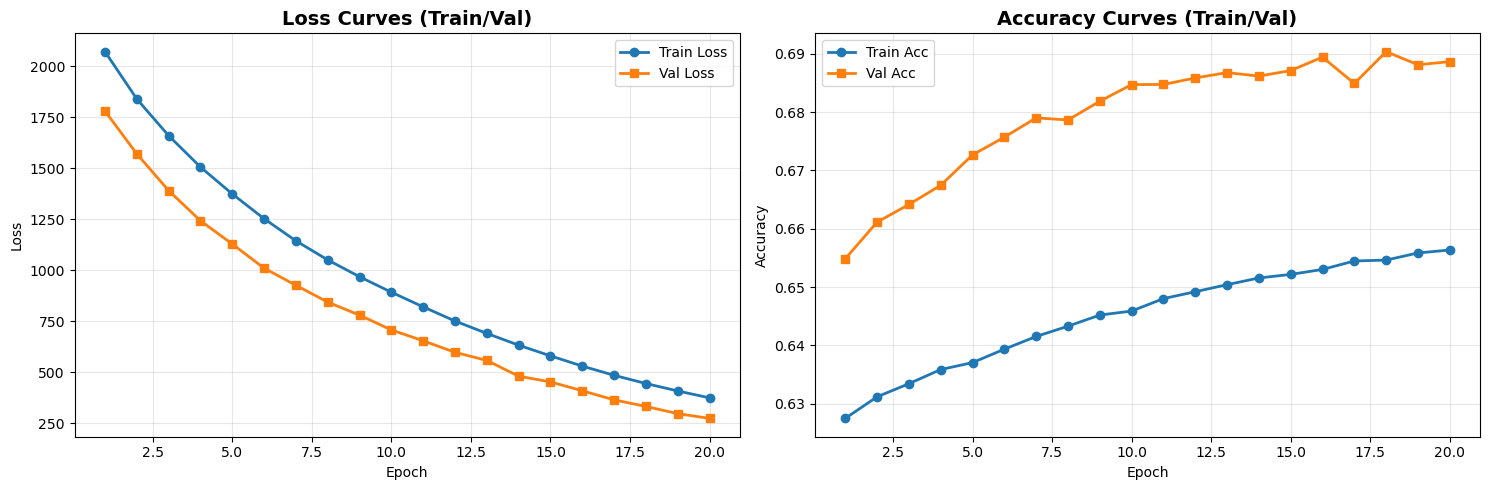


FINAL PERFORMANCE SUMMARY
  Metric    Train      Val
    Loss 373.6924 273.0355
Accuracy   0.6563   0.6886


In [145]:
# 3곡선 러닝커브 플롯
import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))

epochs = np.arange(1, len(train_losses) + 1)

# Loss 곡선
ax1.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_losses, 's-', label='Val Loss', linewidth=2)
ax1.set_title('Loss Curves (Train/Val)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 곡선 
ax2.plot(epochs, train_accs, 'o-', label='Train Acc', linewidth=2)
ax2.plot(epochs, val_accs, 's-', label='Val Acc', linewidth=2)
ax2.set_title('Accuracy Curves (Train/Val)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 요약표
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)

summary_data = {
    'Metric': ['Loss', 'Accuracy'],
    'Train': [f"{train_losses[-1]:.4f}", f"{train_accs[-1]:.4f}"],
    'Val': [f"{val_losses[-1]:.4f}", f"{val_accs[-1]:.4f}"],
}

import pandas as pd
df = pd.DataFrame(summary_data)
print(df.to_string(index=False))


# 성능 측정하기

In [146]:
def generate_answer_from_qa(qa_ids, model, tokenizer,
                            max_len=50, temperature=1.0, top_k=20, device=None):
    if device is None:
        device = CFG["DEVICE"]

    model.eval()
    BOS_ID = 1
    EOS_ID = 2
    SEP_ID = tokenizer.PieceToId("<sep>")  # 학습과 동일한 SEP ID

    sep_pos = qa_ids.index(SEP_ID)
    prompt_ids = qa_ids[:sep_pos + 1]   # [BOS] 질문... [SEP]

    with torch.no_grad():
        ys = torch.tensor([prompt_ids], dtype=torch.long, device=device)  # [1, L_prompt]

        for _ in range(max_len):
            dec_mask = generate_masks(ys)

            logits_all, _ = model(ys, dec_mask)   # [1, L, vocab]
            logits = logits_all[0, -1, :] / temperature

            if top_k > 0:
                topk_logits, topk_idx = torch.topk(logits, top_k)
                mask = torch.full_like(logits, float('-inf'))
                logits = mask.scatter(0, topk_idx, topk_logits)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            next_id = next_token.item()

            ys = torch.cat([ys, next_token.unsqueeze(0)], dim=1)

            if next_id == EOS_ID:
                break

        all_ids = ys[0].tolist()
        answer_ids = all_ids[sep_pos + 1:]

        if len(answer_ids) > 0 and answer_ids[-1] == EOS_ID:
            answer_ids = answer_ids[:-1]

        # check --------------------------------------------
        # print("DEBUG all_ids:", all_ids)
        # print("DEBUG answer_ids:", answer_ids)
        # if len(answer_ids) > 0:
        #     print("DEBUG first 10 pieces:")
        #     for tid in answer_ids[:10]:
        #         print(" ", tid, "→", tokenizer.IdToPiece(tid))
        # check --------------------------------------------

        gen_answer = tokenizer.DecodeIds(answer_ids) if len(answer_ids) > 0 else ""
        full_decoded = tokenizer.DecodeIds(all_ids)

        return gen_answer, full_decoded


In [153]:
for i in [0, 10, 100]:
    # 디버깅용: 질문/정답 실제 텍스트
    q = tokenizer.decode_ids(sum([s[1:-1] for s in enc_train[i]], []))
    a = tokenizer.decode_ids(sum([s[1:-1] for s in dec_train[i]], []))
    # q = tokenizer.decode_ids(sum([s[1:-1] for s in enc_test[i]], []))
    # a = tokenizer.decode_ids(sum([s[1:-1] for s in dec_test[i]], []))

    # qa_ids = full_train[i]              # [BOS] 질문 ... <sep> 답 ... EOS
    qa_ids = full_train[i]             # [BOS] 질문 ... <sep> 답 ... EOS
    gen_answer, full = generate_answer_from_qa(
        qa_ids, transformer, tokenizer,
        max_len=50, temperature=1.0, top_k=20
    )

    print(f"=== 샘플 {i} ===")
    print("질문:", q)
    print("정답:", a)
    print("생성 답:", repr(gen_answer))
    print("전체:", full)
    print("-" * 50)


=== 샘플 0 ===
질문: 엄청 로맨틱 해
정답: 생각 만 해도 달콤 하 네요 .
생성 답: '사랑 은 것 같 아요 .'
전체: 엄청 로맨틱 해<sep> 사랑 은 것 같 아요 .
--------------------------------------------------
=== 샘플 10 ===
질문: 가족 들 이랑 어디 가 지 ?
정답: 온 가족 이 모두 마음 에 드 는 곳 으로 가 보 세요 .
생성 답: '자신 의 시간 .'
전체: 가족 들 이랑 어디 가 지 ?<sep> 자신 의 시간 .
--------------------------------------------------
=== 샘플 100 ===
질문: 연애 감흥 이 점점 사라져
정답: 연애 의 모습 이 다양 한 거 예요 .
생성 답: '자신 의 게 지 마세요 .'
전체: 연애 감흥 이 점점 사라져<sep> 자신 의 게 지 마세요 .
--------------------------------------------------


In [156]:
i = 0
qa_ids = full_train[i]  # [BOS] Q SEP A EOS

gen_answer, full = generate_answer_from_qa(
    qa_ids, transformer, tokenizer,
    max_len=50, temperature=1.0, top_k=20, device=CFG["DEVICE"]
)

print("질문/정답/생성:")
print("QA ids:", qa_ids)
print("Full decoded:", full)
print("Gen answer:", repr(gen_answer))


질문/정답/생성:
QA ids: [1, 754, 1147, 1197, 16, 4, 55, 43, 16, 53, 189, 1338, 9, 48, 5, 2]
Full decoded: 엄청 로맨틱 해<sep> 사랑 은 것 같 아요 .
Gen answer: '사랑 은 것 같 아요 .'
